In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import sys
sys.path.append('..')

In [3]:
from represent_data import D4JProcessing

## Remaining Questions

### Utilized bug count 162, instead of 220 for defects4j?

In [4]:
combined_results = '../AutoFL/combined_fl_results/d4j_eol_llama3_R5.json'
with open(combined_results) as f:
    data = json.load(f)
autofl_result = data['buggy_methods']

In [5]:
candidate_bugs = sorted(os.listdir('../AutoFL/data/defects4j'))

count = 0
for bug in candidate_bugs:
    if len(autofl_result[bug]) != 1:
        # print(bug)
        count += 1
count

58

It turned out that the original paper also says that there are 162 d4j bugs, not 220

### Qwen2.5-coder requires argument encoding length > 43

### Llama3 took 11 steps at most, and Llama3.1 12. Why?

# Routing

### Selection of bugs

In [6]:
combined_result_dir = '../AutoFL/combined_fl_results/'
os.listdir(combined_result_dir)

['d4j_eol_mistral-nemo_R5.json',
 'd4j_eol_codellama_R5.json',
 'd4j_eol_llama3_R5.json',
 'd4j_eol_qwen2.5-coder_R5.json',
 'bip_gpt4o_results_R10_full.json',
 'd4j_eol_llama3.1_R5.json',
 'd4j_eol_llama3_R10.json',
 'd4j_eol_gemma2_R5.json',
 'd4j_eol_granite3-dense:8b_R5.json',
 'd4j_gpt4o_results_R10_full.json']

In [7]:
with open(os.path.join(combined_result_dir, 'd4j_gpt4o_results_R10_full.json')) as f:
    gpt_results = json.load(f)
with open(os.path.join(combined_result_dir, 'd4j_eol_llama3_R10.json')) as f:
    llama_results = json.load(f)

In [8]:
def bugs_ranked_at_first(result):
    buggy_methods = result['buggy_methods']
    bugs_at_top1 = set()
    for bug in buggy_methods:
        method_ranks = buggy_methods[bug]
        if method_ranks.values() and min([val['autofl_rank'] for val in method_ranks.values()]) == 1:
            bugs_at_top1.add(bug)
    return bugs_at_top1

In [9]:
gpt_top1 = bugs_ranked_at_first(gpt_results)
llama_top1 = bugs_ranked_at_first(llama_results)
target_bugs = gpt_top1 - llama_top1
len(target_bugs)

71

### Cost Estimation

In [ ]:
model_costs = {
    'gpt-4o': (),
    'llama3': (), # 8B
}

### Vertical Cut, AutoFL confidence

In [10]:
raw_result_dir = '../AutoFL/results/'

In [11]:
def load_gpt_log(run_index, bug):
    path = os.path.join(raw_result_dir, f'd4j_autofl_{run_index + 1}', 'gpt-4o', f'XFL-{bug}.json')
    with open(path) as f:
        log = json.load(f)
    return log

def load_llama_log(run_index, bug):
    path = os.path.join(raw_result_dir, f'd4j_autofl_eol_{run_index + 1}', 'llama3', f'XFL-{bug}.json')
    with open(path) as f:
        log = json.load(f)
    return log

In [12]:
def count_unmatched_runs(model):
    total_unmatched_runs = 0
    per_bug_unmatched_runs = []
    run_count = 10

    for bug in sorted(target_bugs):
        processor = D4JProcessing(bug, '../AutoFL/data/defects4j')
        unmatched_run_per_bug = 0
        for r in range(run_count):
            if model == 'gpt-4o':
                log = load_gpt_log(r, bug)
            elif model == 'llama3':
                log = load_llama_log(r, bug)
            processed_answer_dict = processor.process_answer(log['messages'][-1]['content'])
            answer_list = sum(processed_answer_dict.values(), [])
            if not answer_list:
                total_unmatched_runs += 1
                unmatched_run_per_bug += 1
        per_bug_unmatched_runs.append(unmatched_run_per_bug)
    print(pd.Series(per_bug_unmatched_runs).describe())
    print(total_unmatched_runs, len(target_bugs) * run_count)

In [13]:
count_unmatched_runs('gpt-4o')

count    71.000000
mean      0.211268
std       0.475560
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       2.000000
dtype: float64
15 710


In [14]:
count_unmatched_runs('llama3')

count    71.000000
mean      4.408451
std       2.816165
min       0.000000
25%       2.000000
50%       4.000000
75%       7.000000
max      10.000000
dtype: float64
313 710


In [34]:
def threshold_swap(confidence_calculator, thresholding_predicate, hist=True):
    max_runs = 10

    acc_at_1 = 0
    num_of_llama_trajectories = list()

    for bug in sorted(target_bugs):
        is_swapped = False
        processor = D4JProcessing(bug, '../AutoFL/data/defects4j')
        candidate_methods = dict()
        for r in range(max_runs):
            if is_swapped:
                log = load_gpt_log(r, bug)
            else:
                log = load_llama_log(r, bug)
            processed_answer_dict = processor.process_answer(log['messages'][-1]['content'])
            answer_list = sum(processed_answer_dict.values(), [])

            for candidate in answer_list:
                if candidate not in candidate_methods:
                    candidate_methods[candidate] = 0
                candidate_methods[candidate] += 1 / len(answer_list)
            confidence = confidence_calculator(candidate_methods, r)

            if not is_swapped and thresholding_predicate(confidence, r): # exception for zero confidence?
                is_swapped = True
                num_of_llama_trajectories.append(r + 1)

        if not is_swapped:
            num_of_llama_trajectories.append(max_runs)

        max_confidence = 0
        signature_at_1 = ''
        for candidate, confidence in candidate_methods.items():
            if confidence > max_confidence:
                max_confidence = confidence
                signature_at_1 = candidate
        if processor.is_buggy(signature_at_1):
            acc_at_1 += 1
    
    print(f'Fail->Pass: {acc_at_1} / {len(target_bugs)}')
    print(f'# of GPT-4o Trajectories: {max_runs * len(target_bugs) - sum(num_of_llama_trajectories)} / {max_runs * len(target_bugs)}')
    if hist:
        plt.title('Number of Llama3 Trajectories out of R=10')
        plt.grid(axis='y')
        plt.hist(num_of_llama_trajectories, bins=range(min(num_of_llama_trajectories), max(num_of_llama_trajectories) + 2), align='left', rwidth=0.8)
        plt.xticks(range(min(num_of_llama_trajectories), max(num_of_llama_trajectories) + 1))  # Ensure correct tick positions
        plt.show()
    
    return acc_at_1 / len(target_bugs), (max_runs * len(target_bugs) - sum(num_of_llama_trajectories)) / (max_runs * len(target_bugs))

In [40]:
ftop_ratios = list()
gpt_trajectory_ratios = list()

def unnormalized_confidence(candidate_methods, r):
    return 0 if not candidate_methods.values() else max(candidate_methods.values())

print('Thresholding by r//k vs. unnormalized confidence')
for k in range(1, 11):
    print(f'k={k}')

    def k_threshold(confidence, r):
      return confidence < ((r + 1) // k) 
    
    ftop_ratio, gpt_ratio = threshold_swap(unnormalized_confidence, k_threshold, hist=False)
    ftop_ratios.append(ftop_ratio)
    gpt_trajectory_ratios.append(gpt_ratio)

Thresholding by r//k vs. unnormalized confidence
k=1
Fail->Pass: 67 / 71
# of GPT-4o Trajectories: 618 / 710
k=2
Fail->Pass: 59 / 71
# of GPT-4o Trajectories: 426 / 710
k=3
Fail->Pass: 37 / 71
# of GPT-4o Trajectories: 220 / 710
k=4
Fail->Pass: 18 / 71
# of GPT-4o Trajectories: 104 / 710
k=5
Fail->Pass: 12 / 71
# of GPT-4o Trajectories: 60 / 710
k=6
Fail->Pass: 9 / 71
# of GPT-4o Trajectories: 36 / 710
k=7
Fail->Pass: 6 / 71
# of GPT-4o Trajectories: 24 / 710
k=8
Fail->Pass: 7 / 71
# of GPT-4o Trajectories: 16 / 710
k=9
Fail->Pass: 6 / 71
# of GPT-4o Trajectories: 7 / 710
k=10
Fail->Pass: 0 / 71
# of GPT-4o Trajectories: 0 / 710


In [41]:
def visualize_ratios(gpt_trajectory_ratios, ftop_ratios, do_curve_fit=True):

    plt.xlabel('Ratio of GPT-4o Trajectories')
    plt.ylabel('Ratio of acc@1')
    plt.scatter(gpt_trajectory_ratios, ftop_ratios)
    plt.plot(gpt_trajectory_ratios, ftop_ratios, label='Confidence Thresholding')
    plt.plot([0, 1], [0, 1], linestyle='--', label='y=x')

    if do_curve_fit:
        def fit_func(x, b, c, d):
            return (np.log(x + b) + c) / d

        params, _ = curve_fit(fit_func, gpt_trajectory_ratios, ftop_ratios, p0=[1, 4, 4])

        x_fit = np.linspace(0, 1, 100)
        y_fit = fit_func(x_fit, *params)
        print(params)
        plt.plot(x_fit, y_fit, linestyle='--', label=f'y=(log(x + {params[0]:.1f}) + {params[1]:.1f})/{params[2]:.1f}')

    plt.legend()
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()

[0.34917419 1.08468146 1.31601355]


/var/folders/cy/pnx3rqp534d0ghwqtxn7lb2w0000gn/T/ipykernel_1166/3080160156.py:11: RuntimeWarning: invalid value encountered in log
  return (np.log(x + b) + c) / d


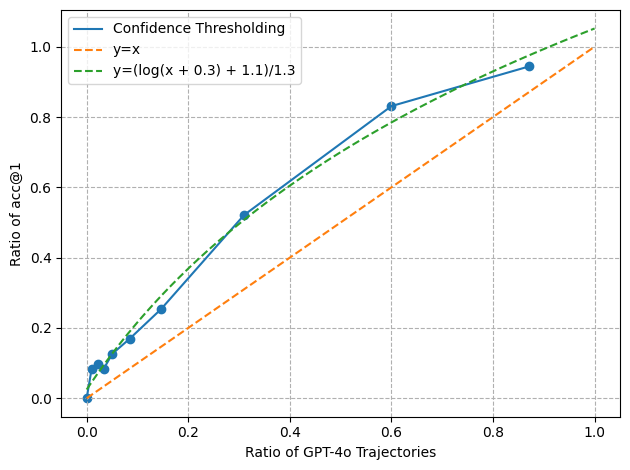

In [42]:
visualize_ratios(gpt_trajectory_ratios, ftop_ratios)

In [43]:
hard_ftop_ratios = list()
hard_gpt_trajectory_ratios = list()

def normalized_confidence(candidate_methods, r):
    return 0 if not candidate_methods.values() else max(candidate_methods.values()) / (r + 1)

print('Thresholding by k * 0.1')
for k in range(1, 11):
    print(f'k={k}')

    def hard_threshold(confidence, r):
      return confidence < k * 0.1
    
    ftop_ratio, gpt_ratio = threshold_swap(normalized_confidence, hard_threshold, hist=False)
    hard_ftop_ratios.append(ftop_ratio)
    hard_gpt_trajectory_ratios.append(gpt_ratio)

Thresholding by k * 0.1
k=1
Fail->Pass: 28 / 71
# of GPT-4o Trajectories: 252 / 710
k=2
Fail->Pass: 32 / 71
# of GPT-4o Trajectories: 269 / 710
k=3
Fail->Pass: 46 / 71
# of GPT-4o Trajectories: 383 / 710
k=4
Fail->Pass: 58 / 71
# of GPT-4o Trajectories: 456 / 710
k=5
Fail->Pass: 62 / 71
# of GPT-4o Trajectories: 499 / 710
k=6
Fail->Pass: 67 / 71
# of GPT-4o Trajectories: 602 / 710
k=7
Fail->Pass: 67 / 71
# of GPT-4o Trajectories: 615 / 710
k=8
Fail->Pass: 67 / 71
# of GPT-4o Trajectories: 618 / 710
k=9
Fail->Pass: 67 / 71
# of GPT-4o Trajectories: 618 / 710
k=10
Fail->Pass: 67 / 71
# of GPT-4o Trajectories: 618 / 710


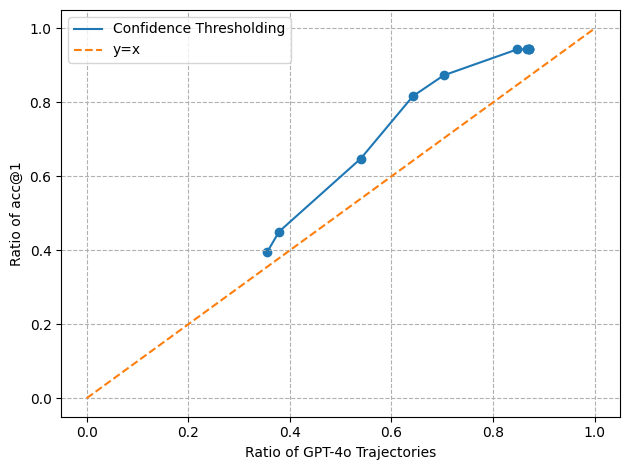

In [44]:
visualize_ratios(hard_gpt_trajectory_ratios, hard_ftop_ratios, do_curve_fit=False)

# Surrogate Navigator